# Canadian Job Market Exploratory Analysis

## January 2025

This notebook analyzes hiring demand, advertised vacancies, salary patterns, and salary transparency using Canadian Job Bank postings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")

In [2]:
processed_path = Path(
    "../data/processed/job_bank_jan_2025_clean.parquet"
)

jobs = pd.read_parquet(processed_path)

print("Rows:", f"{jobs.shape[0]:,}")
print("Columns:", jobs.shape[1])
jobs.head()

Rows: 101,570
Columns: 68


,wic_job_location_snapshot_id,job_title,original_job_title,noc_2016_code,noc_2016_code_name,noc21_code,noc21_code_name,external_indicator,first_posting_date,vacancy_count,...,hours_per,hours_minimum,hours_maximum,work_hours,work_hours_from_time,work_hours_to_time,hourly_salary_minimum,hourly_salary_maximum,hourly_salary_midpoint,salary_valid_for_analysis
0,14108325,retail sales representative,Remote Sales Representative (No Cold Calling),6421.0,Retail salespersons,64100.0,Retail salespersons and visual merchandisers,1,2025-01-10,1,...,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,False
1,14131905,business development officer,Business Development Representative,4163.0,Business development officers and marketing re...,41402.0,Business development officers and market resea...,1,2025-01-15,1,...,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,False
2,14170021,financial accountant,NaN,1111.0,Financial auditors and accountants,11100.0,Financial auditors and accountants,1,2025-01-29,1,...,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,False
3,14122545,Christmas tree shearer,NaN,8432.0,Nursery and greenhouse workers,85103.0,Nursery and greenhouse labourers,0,2025-01-16,30,...,Week,40.0,60.0,No,NaN,NaN,15.47,15.47,15.47,True
4,14072526,administrative coordinator,(PTL Canada) Operations Coordinator,1221.0,Administrative officers,13100.0,Administrative officers,1,2025-01-01,1,...,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,False


## 1. National Market Overview

This section summarizes the overall size, salary coverage, geographic coverage, and occupational diversity of the January 2025 Job Bank dataset.

In [3]:
national_kpis = pd.DataFrame({
    "Metric": [
        "Unique job postings",
        "Advertised vacancies",
        "Provinces and territories",
        "NOC 2021 occupations",
        "Median hourly salary",
        "Salary coverage",
        "First posting date",
        "Last posting date"
    ],
    "Value": [
        f"{len(jobs):,}",
        f"{int(jobs['vacancy_count'].sum()):,}",
        f"{jobs['province_territory'].nunique():,}",
        f"{jobs['noc21_code'].nunique():,}",
        f"${jobs['hourly_salary_midpoint'].median():,.2f}",
        f"{jobs['salary_valid_for_analysis'].mean() * 100:.1f}%",
        jobs["first_posting_date"].min().strftime("%d %b %Y"),
        jobs["first_posting_date"].max().strftime("%d %b %Y")
    ]
})

national_kpis

,Metric,Value
0,Unique job postings,"101,570"
1,Advertised vacancies,"139,697"
2,Provinces and territories,13
3,NOC 2021 occupations,494
4,Median hourly salary,$25.53
5,Salary coverage,52.1%
6,First posting date,01 Jan 2025
7,Last posting date,31 Jan 2025


## 2. Occupation Demand

Demand is measured using both unique postings and advertised vacancies. Vacancy totals are important because a single posting may advertise multiple available positions.

In [4]:
occupation_summary = (
    jobs
    .dropna(subset=["noc21_code", "noc21_code_name"])
    .groupby(
        ["noc21_code", "noc21_code_name"],
        as_index=False
    )
    .agg(
        posting_count=("wic_job_location_snapshot_id", "count"),
        total_vacancies=("vacancy_count", "sum"),
        valid_salary_postings=("salary_valid_for_analysis", "sum"),
        median_hourly_salary=("hourly_salary_midpoint", "median")
    )
)

occupation_summary["vacancies_per_posting"] = (
    occupation_summary["total_vacancies"]
    / occupation_summary["posting_count"]
).round(2)

occupation_summary["salary_coverage_percentage"] = (
    occupation_summary["valid_salary_postings"]
    / occupation_summary["posting_count"]
    * 100
).round(1)

occupation_summary.sort_values(
    "total_vacancies",
    ascending=False
).head(15)

,noc21_code,noc21_code_name,posting_count,total_vacancies,valid_salary_postings,median_hourly_salary,vacancies_per_posting,salary_coverage_percentage
284,64100.0,Retail salespersons and visual merchandisers,6381,6688,1503,20.500000,1.05,23.6
277,63200.0,Cooks,2931,5161,2465,19.000000,1.76,84.1
263,62020.0,Food service supervisors,2418,5112,2272,18.650000,2.11,94.0
381,73300.0,Transport truck drivers,2143,4671,1096,29.250000,2.18,51.1
305,65201.0,"Food counter attendants, kitchen helpers and r...",1682,4020,1400,17.350000,2.39,83.2
298,64409.0,Other customer and information services repres...,3141,3427,623,20.913462,1.09,19.8
422,85101.0,Harvesting labourers,202,2919,199,17.400000,14.45,98.5
397,75110.0,Construction trades helpers and labourers,1086,2530,830,25.000000,2.33,76.4
42,13110.0,Administrative assistants,2281,2478,1751,25.640000,1.09,76.8
270,62101.0,Retail and wholesale buyers,2166,2194,145,18.000000,1.01,6.7


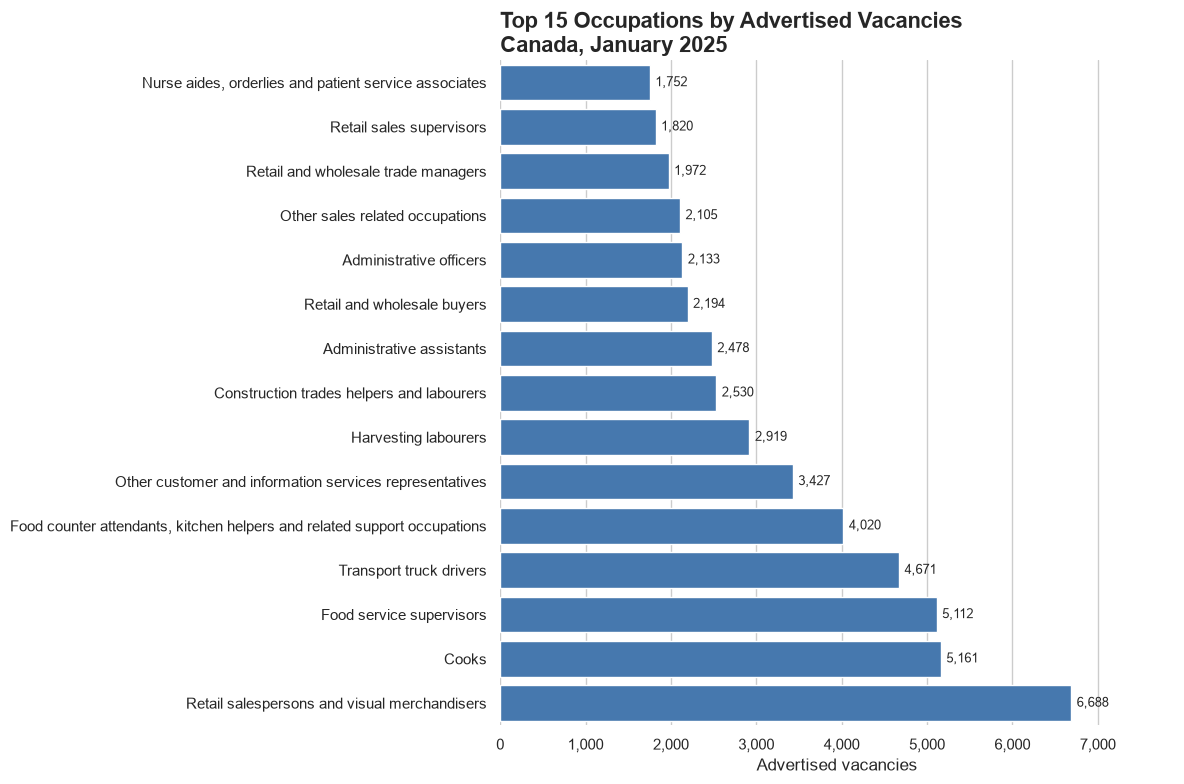

In [5]:
top_occupations = (
    occupation_summary
    .nlargest(15, "total_vacancies")
    .sort_values("total_vacancies", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=top_occupations,
    x="total_vacancies",
    y="noc21_code_name",
    color="#3478C0",
    ax=ax
)

ax.set_title(
    "Top 15 Occupations by Advertised Vacancies\nCanada, January 2025",
    loc="left",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Advertised vacancies")
ax.set_ylabel("")
ax.set_xlim(
    0,
    top_occupations["total_vacancies"].max() * 1.18
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"{value:,.0f}"
        for value in top_occupations["total_vacancies"]
    ],
    padding=4,
    fontsize=9
)

sns.despine(left=True, bottom=True)
plt.tight_layout()

figures_path = Path("../reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_path / "top_occupations_by_vacancies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Advertised Salary Patterns

Salary comparisons use the normalized hourly midpoint and include only postings that passed the salary-validity checks. Occupation rankings require a minimum number of valid salary observations to reduce the influence of very small samples.

In [6]:
valid_salary_jobs = jobs[
    jobs["salary_valid_for_analysis"]
].copy()

national_salary_summary = (
    valid_salary_jobs["hourly_salary_midpoint"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    )
    .round(2)
)

national_salary_summary

count    52896.00
mean        29.13
std         15.42
min         10.00
10%         17.50
25%         20.00
50%         25.53
75%         34.10
90%         42.50
max        437.50
Name: hourly_salary_midpoint, dtype: float64

In [7]:
MINIMUM_SALARY_SAMPLE = 50

salary_by_occupation = (
    occupation_summary[
        occupation_summary["valid_salary_postings"]
        >= MINIMUM_SALARY_SAMPLE
    ]
    .sort_values(
        "median_hourly_salary",
        ascending=False
    )
)

salary_by_occupation[
    [
        "noc21_code_name",
        "posting_count",
        "valid_salary_postings",
        "salary_coverage_percentage",
        "median_hourly_salary"
    ]
].head(15)

,noc21_code_name,posting_count,valid_salary_postings,salary_coverage_percentage,median_hourly_salary
129,Specialists in clinical and laboratory medicine,76,53,69.7,156.250000
131,General practitioners and family physicians,137,94,68.6,149.111635
133,Dentists,133,60,45.1,103.586704
2,"Senior managers - financial, communications an...",95,76,80.0,85.538462
138,Psychologists,107,63,58.9,70.000000
146,Nurse practitioners,271,179,66.1,57.750000
5,"Senior managers - construction, transportation...",104,101,97.1,54.000000
136,Pharmacists,1099,124,11.3,54.000000
67,Computer and information systems managers,334,61,18.3,52.730048
139,Chiropractors,143,117,81.8,51.792671


In [8]:
province_salary_summary = (
    jobs
    .dropna(subset=["province_territory"])
    .groupby("province_territory")
    .agg(
        posting_count=("wic_job_location_snapshot_id", "count"),
        valid_salary_postings=("salary_valid_for_analysis", "sum"),
        median_hourly_salary=("hourly_salary_midpoint", "median"),
        lower_quartile_salary=(
            "hourly_salary_midpoint",
            lambda values: values.quantile(0.25)
        ),
        upper_quartile_salary=(
            "hourly_salary_midpoint",
            lambda values: values.quantile(0.75)
        )
    )
)

province_salary_summary["salary_coverage_percentage"] = (
    province_salary_summary["valid_salary_postings"]
    / province_salary_summary["posting_count"]
    * 100
).round(1)

province_salary_summary = province_salary_summary.sort_values(
    "median_hourly_salary",
    ascending=False
)

province_salary_summary.round(2)

,posting_count,valid_salary_postings,median_hourly_salary,lower_quartile_salary,upper_quartile_salary,salary_coverage_percentage
province_territory,,,,,,
Nunavut,44,31,38.88,30.68,46.93,70.5
Northwest Territories,211,120,28.51,20.00,42.32,56.9
British Columbia,17648,12100,28.00,21.00,35.00,68.6
Ontario,34638,16574,26.50,20.00,34.50,47.8
Alberta,12591,7486,25.00,18.62,32.45,59.5
Québec,20410,7789,25.00,20.00,32.34,38.2
Saskatchewan,5759,3661,24.01,22.75,35.85,63.6
Manitoba,2544,1398,24.00,18.00,30.00,55.0
Yukon,316,197,23.71,20.00,32.50,62.3


In [9]:
print(
    "Valid salary postings:",
    f"{len(valid_salary_jobs):,}"
)

print(
    "Salary coverage:",
    f"{len(valid_salary_jobs) / len(jobs) * 100:.1f}%"
)

print(
    "Occupations meeting the minimum sample:",
    f"{len(salary_by_occupation):,}"
)

Valid salary postings: 52,896
Salary coverage: 52.1%
Occupations meeting the minimum sample: 191


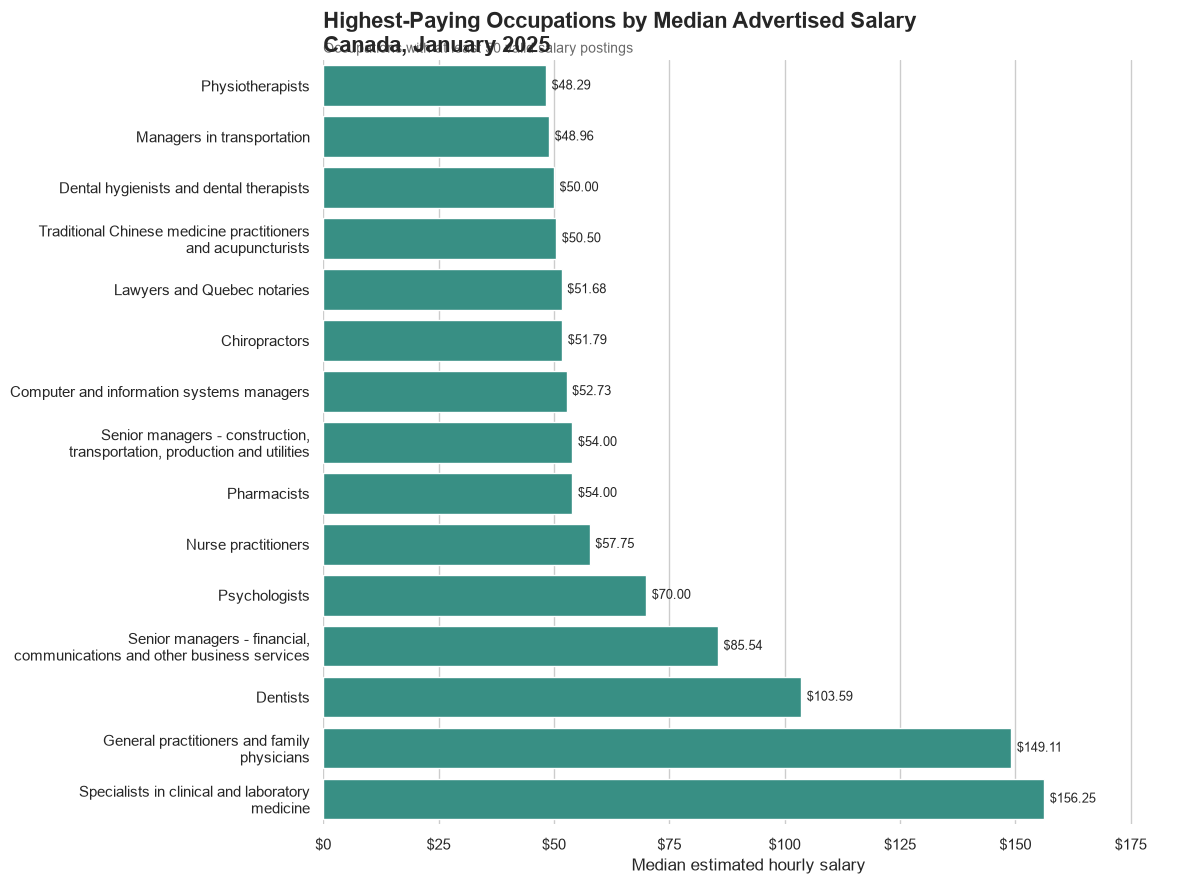

In [10]:
import textwrap

salary_chart = (
    salary_by_occupation
    .head(15)
    .sort_values("median_hourly_salary", ascending=True)
    .copy()
)

salary_chart["occupation_label"] = (
    salary_chart["noc21_code_name"]
    .apply(lambda name: "\n".join(textwrap.wrap(name, width=42)))
)

fig, ax = plt.subplots(figsize=(12, 9))

sns.barplot(
    data=salary_chart,
    x="median_hourly_salary",
    y="occupation_label",
    color="#2A9D8F",
    ax=ax
)

ax.set_title(
    "Highest-Paying Occupations by Median Advertised Salary\n"
    "Canada, January 2025",
    loc="left",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    0,
    1.01,
    "Occupations with at least 50 valid salary postings",
    transform=ax.transAxes,
    fontsize=10,
    color="dimgray"
)

ax.set_xlabel("Median estimated hourly salary")
ax.set_ylabel("")
ax.set_xlim(
    0,
    salary_chart["median_hourly_salary"].max() * 1.18
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"${value:,.0f}")
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"${value:,.2f}"
        for value in salary_chart["median_hourly_salary"]
    ],
    padding=4,
    fontsize=9
)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig(
    figures_path / "highest_paying_occupations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Salary Findings

Among occupations with at least 50 valid salary observations, specialists in clinical and laboratory medicine recorded the highest median advertised hourly salary at approximately $156.25, followed by general practitioners and family physicians at approximately $149.11. Dentists ranked third at approximately $103.59.

Healthcare professions dominate the highest-paying occupations, while senior management and technology-management roles also appear in the ranking. Across all valid postings, the national median advertised salary was $25.53 per hour, with the middle 50% ranging from approximately $20.00 to $34.10.

These rankings should be interpreted alongside salary coverage. Some occupations, including pharmacists and computer and information systems managers, disclosed salaries in a relatively small proportion of postings. The values represent advertised salary-range midpoints from Job Bank postings, not the earnings of all Canadian workers.

### Provincial Salary Findings

Among the four largest provincial job markets, British Columbia had the highest median advertised hourly salary at $28.00, followed by Ontario at $26.50. Alberta and Québec both recorded medians of approximately $25.00.

Nunavut recorded a higher median, but this result was based on only 31 valid salary postings and should not be directly compared with large provincial markets. Salary transparency also varied substantially: British Columbia reported valid salaries for 68.6% of postings, compared with 47.8% in Ontario and 38.2% in Québec.

## 4. Business Analytics and AI Job Market

This section isolates postings whose advertised titles contain selected analytics, business-intelligence, information-systems, data-science, or AI terms. The results provide a targeted view of hiring demand relevant to analytics-oriented job seekers.

Because this is a keyword-based classification, it may exclude relevant roles with unusual titles or include some roles with overlapping terminology.

In [11]:
import re

analytics_keywords = [
    "data analyst",
    "business analyst",
    "business intelligence",
    "data scientist",
    "machine learning",
    "artificial intelligence",
    "analytics analyst",
    "reporting analyst",
    "insights analyst",
    "operations analyst",
    "systems analyst",
    "information systems analyst",
    "market research analyst"
]

analytics_pattern = "|".join(
    re.escape(keyword)
    for keyword in analytics_keywords
)

In [12]:
combined_job_title = (
    jobs["job_title"].fillna("")
    + " "
    + jobs["original_job_title"].fillna("")
)

jobs["analytics_role"] = combined_job_title.str.contains(
    analytics_pattern,
    case=False,
    regex=True,
    na=False
)

analytics_jobs = jobs[jobs["analytics_role"]].copy()

print(
    "Analytics-related postings:",
    f"{len(analytics_jobs):,}"
)

print(
    "Analytics-related vacancies:",
    f"{int(analytics_jobs['vacancy_count'].sum()):,}"
)

Analytics-related postings: 810
Analytics-related vacancies: 817


In [13]:
analytics_kpis = pd.DataFrame({
    "Metric": [
        "Analytics-related postings",
        "Advertised vacancies",
        "Median hourly salary",
        "Salary coverage",
        "Provinces and territories",
        "Cities represented"
    ],
    "Value": [
        f"{len(analytics_jobs):,}",
        f"{int(analytics_jobs['vacancy_count'].sum()):,}",
        f"${analytics_jobs['hourly_salary_midpoint'].median():,.2f}",
        (
            f"{analytics_jobs['salary_valid_for_analysis'].mean() * 100:.1f}%"
        ),
        f"{analytics_jobs['province_territory'].nunique():,}",
        f"{analytics_jobs['city'].nunique():,}"
    ]
})

analytics_kpis

,Metric,Value
0,Analytics-related postings,810
1,Advertised vacancies,817
2,Median hourly salary,$43.30
3,Salary coverage,10.9%
4,Provinces and territories,9
5,Cities represented,90


In [14]:
analytics_location_summary = (
    analytics_jobs
    .dropna(subset=["province_territory", "city"])
    .groupby(
        ["province_territory", "city"],
        as_index=False
    )
    .agg(
        posting_count=("wic_job_location_snapshot_id", "count"),
        total_vacancies=("vacancy_count", "sum"),
        valid_salary_postings=("salary_valid_for_analysis", "sum"),
        median_hourly_salary=("hourly_salary_midpoint", "median")
    )
)

analytics_location_summary["salary_coverage_percentage"] = (
    analytics_location_summary["valid_salary_postings"]
    / analytics_location_summary["posting_count"]
    * 100
).round(1)

analytics_location_summary.sort_values(
    "posting_count",
    ascending=False
).head(15)

,province_territory,city,posting_count,total_vacancies,valid_salary_postings,median_hourly_salary,salary_coverage_percentage
48,Ontario,Toronto,348,350,9,43.500000,2.6
62,Québec,Montréal,70,70,5,38.461538,7.1
40,Ontario,Mississauga,28,29,8,43.000000,28.6
0,Alberta,Calgary,27,27,1,47.500000,3.7
64,Québec,Québec,25,25,3,45.673077,12.0
12,British Columbia,Vancouver,24,24,8,46.133077,33.3
14,Manitoba,Winnipeg,17,17,3,44.000000,17.6
44,Ontario,Ottawa,17,18,2,41.246154,11.8
39,Ontario,Markham,16,16,1,27.163462,6.2
25,Ontario,Brampton,15,15,3,42.000000,20.0


In [15]:
analytics_occupation_summary = (
    analytics_jobs
    .dropna(subset=["noc21_code_name"])
    .groupby("noc21_code_name")
    .agg(
        posting_count=("wic_job_location_snapshot_id", "count"),
        total_vacancies=("vacancy_count", "sum"),
        median_hourly_salary=("hourly_salary_midpoint", "median")
    )
    .sort_values("posting_count", ascending=False)
)

analytics_occupation_summary.head(15)

,posting_count,total_vacancies,median_hourly_salary
noc21_code_name,,,
Professional occupations in business management consulting,275,275,44.000000
Business systems specialists,156,162,43.300000
Database analysts and data administrators,155,155,47.000000
Data scientists,93,94,27.163462
Information systems specialists,35,35,43.437108
Economists and economic policy researchers and analysts,30,30,44.560000
Software developers and programmers,13,13,37.514423
Computer and information systems managers,9,9,NaN
Financial auditors and accountants,9,9,NaN


In [16]:
analytics_city_ranking = (
    analytics_location_summary
    .sort_values("posting_count", ascending=False)
    .copy()
)

located_analytics_postings = (
    analytics_city_ranking["posting_count"].sum()
)

largest_city_share = (
    analytics_city_ranking.iloc[0]["posting_count"]
    / located_analytics_postings
    * 100
)

top_five_city_share = (
    analytics_city_ranking.head(5)["posting_count"].sum()
    / located_analytics_postings
    * 100
)

print(
    "Largest city:",
    analytics_city_ranking.iloc[0]["city"]
)

print(
    "Largest-city share:",
    f"{largest_city_share:.1f}%"
)

print(
    "Top-five-city share:",
    f"{top_five_city_share:.1f}%"
)

Largest city: Toronto
Largest-city share: 44.3%
Top-five-city share: 63.4%


In [17]:
analytics_city_chart = (
    analytics_city_ranking
    .head(15)
    .copy()
)

analytics_city_chart["location"] = (
    analytics_city_chart["city"]
    + ", "
    + analytics_city_chart["province_territory"]
)

analytics_city_chart = analytics_city_chart.sort_values(
    "posting_count",
    ascending=True
)

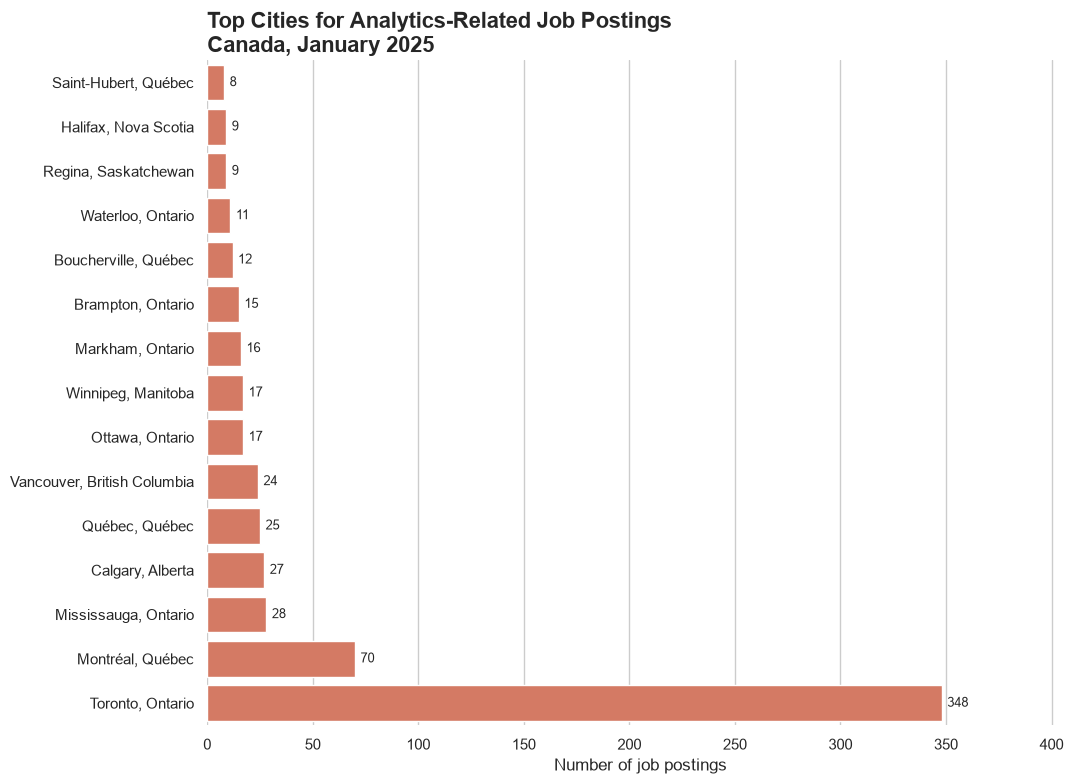

In [18]:
fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=analytics_city_chart,
    x="posting_count",
    y="location",
    color="#E76F51",
    ax=ax
)

ax.set_title(
    "Top Cities for Analytics-Related Job Postings\n"
    "Canada, January 2025",
    loc="left",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Number of job postings")
ax.set_ylabel("")
ax.set_xlim(
    0,
    analytics_city_chart["posting_count"].max() * 1.18
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"{value:,.0f}"
        for value in analytics_city_chart["posting_count"]
    ],
    padding=4,
    fontsize=9
)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig(
    figures_path / "analytics_postings_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analytics-Market Concentration

Toronto was the leading location for analytics-related Job Bank postings in January 2025, followed by Montréal. The results indicate that the targeted analytics market is geographically concentrated in a small number of major Canadian cities.

This concentration has practical implications for job seekers and employers. Candidates may encounter a substantially larger number of relevant opportunities in major urban markets, while employers outside these locations may face a smaller local analytics talent pool.

The location ranking uses posting volume rather than advertised salary because salary-reporting coverage is limited and uneven across cities. The keyword-based definition also means the results should be interpreted as an estimate of the analytics market rather than a complete count.

## 5. Employment Conditions and Qualifications

This section examines employment type, employment term, education, and experience requirements. Missing education or experience information means the requirement was not reported in the dataset; it does not necessarily mean that no qualification was required.


In [19]:
def categorical_summary(data, column):
    summary = (
        data[column]
        .fillna("Not reported")
        .value_counts()
        .rename_axis(column)
        .reset_index(name="posting_count")
    )

    summary["percentage"] = (
        summary["posting_count"]
        / len(data)
        * 100
    ).round(1)

    return summary

In [20]:
employment_type_summary = categorical_summary(
    jobs,
    "employment_type"
)

employment_type_summary

,employment_type,posting_count,percentage
0,Full time,59026,58.1
1,Not reported,29080,28.6
2,Part time,12531,12.3
3,Part time leading to full time,933,0.9


In [21]:
employment_term_summary = categorical_summary(
    jobs,
    "employment_term"
)

employment_term_summary

,employment_term,posting_count,percentage
0,Permanent employment,47149,46.4
1,Not reported,44952,44.3
2,Term or contract,5673,5.6
3,Casual employment,2295,2.3
4,Seasonal employment,1501,1.5


In [22]:
qualification_columns = [
    "education_los",
    "experience_level"
]

qualification_coverage = pd.DataFrame({
    "field": qualification_columns,
    "reported_postings": [
        jobs[column].notna().sum()
        for column in qualification_columns
    ],
    "missing_postings": [
        jobs[column].isna().sum()
        for column in qualification_columns
    ],
    "coverage_percentage": [
        jobs[column].notna().mean() * 100
        for column in qualification_columns
    ]
})

qualification_coverage["coverage_percentage"] = (
    qualification_coverage["coverage_percentage"]
    .round(1)
)

qualification_coverage

,field,reported_postings,missing_postings,coverage_percentage
0,education_los,25789,75781,25.4
1,experience_level,25789,75781,25.4


In [23]:
education_summary = categorical_summary(
    jobs[jobs["education_los"].notna()],
    "education_los"
)

education_summary

,education_los,posting_count,percentage
0,Secondary (high) school graduation certificate,13443,52.1
1,"No degree, certificate or diploma",5342,20.7
2,College/CEGEP,1786,6.9
3,Bachelor's degree,1683,6.5
4,"College, CEGEP or other non-university certifi...",1507,5.8
5,Other trades certificate or diploma,994,3.9
6,"College, CEGEP or other non-university certifi...",463,1.8
7,Registered Apprenticeship certificate,206,0.8
8,"Degree in medicine, dentistry, veterinary medi...",142,0.6
9,Master's degree,140,0.5


In [24]:
experience_summary = categorical_summary(
    jobs[jobs["experience_level"].notna()],
    "experience_level"
)

experience_summary

,experience_level,posting_count,percentage
0,1 year to less than 2 years,8487,32.9
1,No experience,6531,25.3
2,2 years to less than 3 years,3480,13.5
3,7 months to less than 1 year,2441,9.5
4,1 to less than 7 months,2078,8.1
5,3 years to less than 5 years,1755,6.8
6,5 years or more,1017,3.9


In [25]:
analytics_education_summary = categorical_summary(
    analytics_jobs[analytics_jobs["education_los"].notna()],
    "education_los"
)

analytics_education_summary

,education_los,posting_count,percentage
0,Bachelor's degree,31,68.9
1,College/CEGEP,8,17.8
2,Master's degree,3,6.7
3,"College, CEGEP or other non-university certifi...",3,6.7


In [26]:
analytics_experience_summary = categorical_summary(
    analytics_jobs[analytics_jobs["experience_level"].notna()],
    "experience_level"
)

analytics_experience_summary

,experience_level,posting_count,percentage
0,1 year to less than 2 years,14,31.1
1,2 years to less than 3 years,12,26.7
2,5 years or more,7,15.6
3,3 years to less than 5 years,4,8.9
4,7 months to less than 1 year,4,8.9
5,No experience,3,6.7
6,1 to less than 7 months,1,2.2


In [27]:
coverage_comparison = pd.DataFrame({
    "field": [
        "Salary",
        "Education",
        "Experience",
        "Employment type",
        "Employment term"
    ],

    "All postings": [
        jobs["salary_valid_for_analysis"].mean() * 100,
        jobs["education_los"].notna().mean() * 100,
        jobs["experience_level"].notna().mean() * 100,
        jobs["employment_type"].notna().mean() * 100,
        jobs["employment_term"].notna().mean() * 100
    ],

    "Analytics postings": [
        analytics_jobs["salary_valid_for_analysis"].mean() * 100,
        analytics_jobs["education_los"].notna().mean() * 100,
        analytics_jobs["experience_level"].notna().mean() * 100,
        analytics_jobs["employment_type"].notna().mean() * 100,
        analytics_jobs["employment_term"].notna().mean() * 100
    ]
})

coverage_comparison = coverage_comparison.round(1)
coverage_comparison

,field,All postings,Analytics postings
0,Salary,52.1,10.9
1,Education,25.4,5.6
2,Experience,25.4,5.6
3,Employment type,71.4,34.8
4,Employment term,55.7,29.4


In [28]:
coverage_chart_data = coverage_comparison.melt(
    id_vars="field",
    var_name="market",
    value_name="coverage_percentage"
)

coverage_chart_data

,field,market,coverage_percentage
0,Salary,All postings,52.1
1,Education,All postings,25.4
2,Experience,All postings,25.4
3,Employment type,All postings,71.4
4,Employment term,All postings,55.7
5,Salary,Analytics postings,10.9
6,Education,Analytics postings,5.6
7,Experience,Analytics postings,5.6
8,Employment type,Analytics postings,34.8
9,Employment term,Analytics postings,29.4


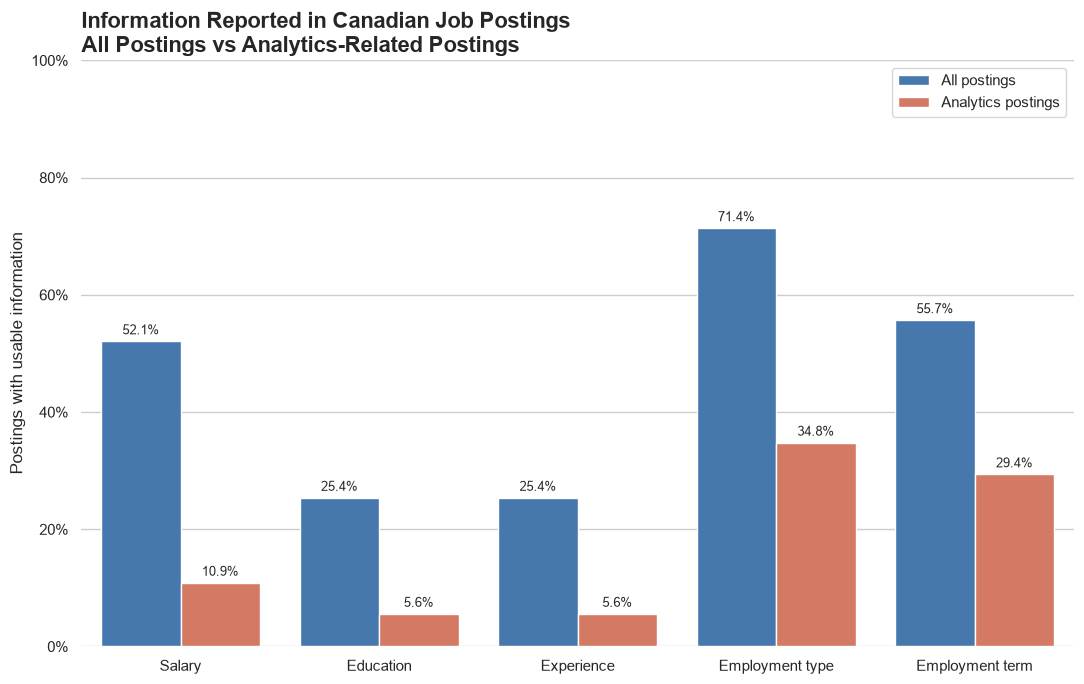

In [29]:
fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=coverage_chart_data,
    x="field",
    y="coverage_percentage",
    hue="market",
    palette=["#3478C0", "#E76F51"],
    ax=ax
)

ax.set_title(
    "Information Reported in Canadian Job Postings\n"
    "All Postings vs Analytics-Related Postings",
    loc="left",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Postings with usable information")
ax.set_ylim(0, 100)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:.0f}%")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

ax.legend(title="")
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig(
    figures_path / "information_coverage_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Key Findings and Limitations

### Key Findings

- Ontario recorded the largest number of postings and advertised vacancies, followed by Québec, British Columbia, and Alberta.
- Retail, food service, transport, administrative support, and healthcare-support occupations generated substantial vacancy demand.
- The median valid advertised salary was approximately $25.53 per hour.
- Healthcare professions dominated the highest-paying occupation rankings.
- Analytics-related opportunities were geographically concentrated, particularly in Toronto and Montréal.
- Reported analytics salaries were higher than the overall market median, although title-based selection and incomplete reporting affect this comparison.
- Full-time and permanent employment were the largest explicitly reported employment categories.

### Limitations

- The analysis covers only January 2025 and cannot yet measure changes over time.
- Salary, education, experience, and employment conditions were not consistently reported.
- Salary-period errors required plausibility filtering, and uncertain values were excluded rather than corrected.
- Analytics roles were identified through job-title keywords, which may create false positives or omit relevant positions.
- Job Bank postings do not represent every job advertised in Canada.
- Small geographic and occupational samples should not be compared directly with major labour markets.